# Notebook 1: Data Exploration, Cleaning & Feature Engineering
**Phase 1 + 2 of the hackathon plan**

Goal: Load all raw files, fix data quality issues, build one clean master table, and create all features.

## Step 1 — Setup & Load Data

In [1]:
import sys
sys.path.append("../03_scripts")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_prep import load_raw_files, fix_data_quality, build_master_table, build_test_table, save_processed
from utils import yyyymm_to_date, print_data_summary

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
print("Libraries loaded OK")

Libraries loaded OK


## Step 2 — Load All Raw Files

In [2]:
data = load_raw_files()

# Quick peek at each file
for name, df in data.items():
    print(f"{name:20s}: {df.shape[0]:>7,} rows x {df.shape[1]:>3} cols | cols: {list(df.columns[:5])}")

Loaded sales: 71,831 rows
Loaded payer: 81,360 rows
Loaded promotion: 33,040 rows
Loaded price: 1,080 rows
Loaded epidemiology: 3,200 rows
Loaded forecast: 3,840 rows
Loaded geo: 80 rows
Loaded product: 20 rows
Loaded indication: 8 rows
Loaded prod_ind: 27 rows
Loaded payer_bob: 4 rows
Loaded test: 3,840 rows
Loaded submission: 3,840 rows
sales               :  71,831 rows x  15 cols | cols: ['date_year_month', 'date_year_quarter', 'date_year', 'ecosystem_id', 'ecosystem_name']
payer               :  81,360 rows x  10 cols | cols: ['date_year_month', 'ecosystem_id', 'product_brand_id', 'product_brand_name', 'pct_lives_covered']
promotion           :  33,040 rows x  11 cols | cols: ['date_year_month', 'ecosystem_id', 'product_brand_id', 'product_brand_name', 'rep_calls']
price               :   1,080 rows x   6 cols | cols: ['date_year_month', 'product_brand_id', 'product_brand_name', 'list_wac_per_unit', 'gross_to_net_ratio']
epidemiology        :   3,200 rows x  12 cols | cols: ['ecos

## Step 3 — Fix Data Quality Issues

In [3]:
data["sales"] = fix_data_quality(data["sales"])
print("Sample after cleaning:")
data["sales"].head(3)

Removed 71 duplicate rows
Flagged 40 negative dollar rows
Flagged 440 DDD lag rows (months: [np.int64(202411), np.int64(202412)])
Sample after cleaning:


,date_year_month,date_year_quarter,date_year,ecosystem_id,ecosystem_name,product_brand_id,product_brand_name,market_code,flag_competitor,data_provider_name,sale_channel_type,iqvia_sales_qty_eqv,iqvia_sales_tot_rx_count,iqvia_sales_new_rx_count,iqvia_sales_dollars,flag_negative_dollars,flag_ddd_lag
0,202101,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,NON-RETAIL,135.111,135.111,22.380,263466.34,0,0
1,202102,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,NON-RETAIL,117.951,117.951,29.227,230384.70,0,0
2,202103,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,NON-RETAIL,103.571,103.571,28.986,202630.98,0,0


## Step 4 — Explore Sales History

Look at overall trends before building the model.

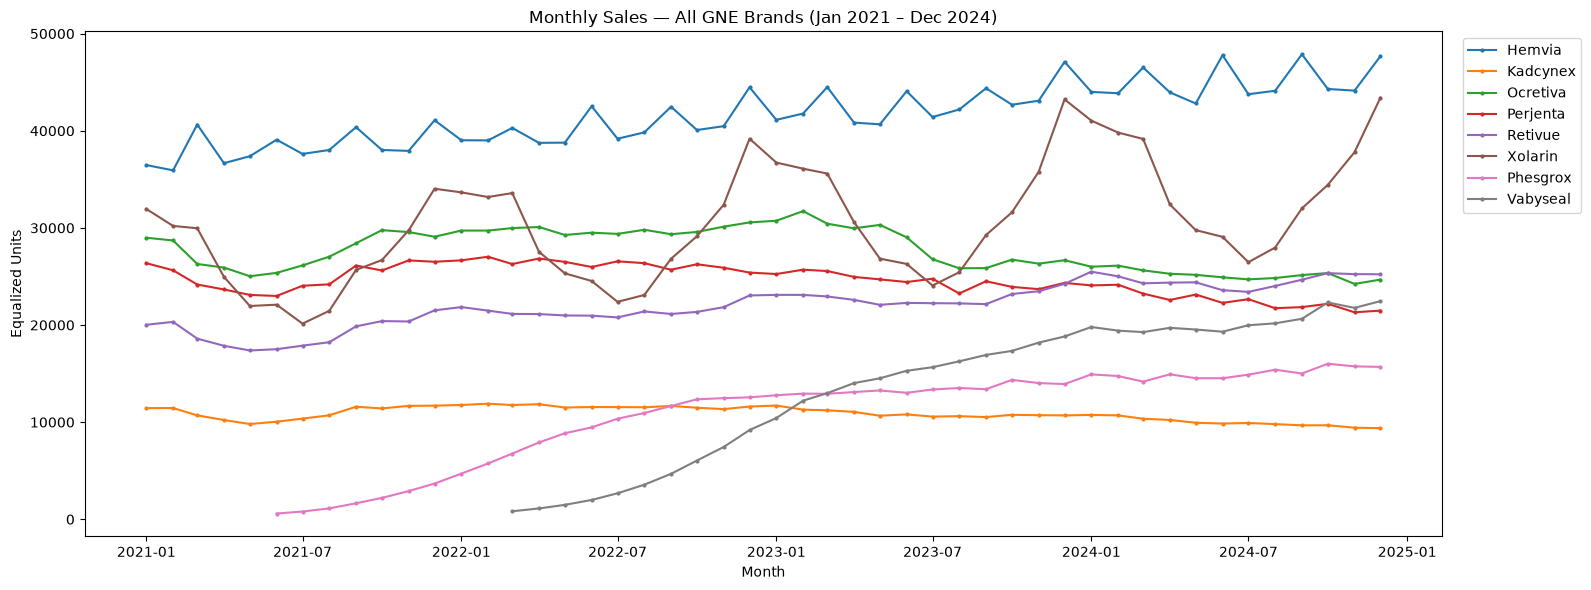

In [4]:
sales = data["sales"].copy()
sales["date"] = yyyymm_to_date(sales["date_year_month"])

# GNE brands only
gne_sales = sales[sales["flag_competitor"] == "N"]

# Total monthly sales by brand
brand_monthly = gne_sales.groupby(["date", "product_brand_name"])["iqvia_sales_qty_eqv"].sum().reset_index()

plt.figure(figsize=(16, 6))
for brand in brand_monthly["product_brand_name"].unique():
    sub = brand_monthly[brand_monthly["product_brand_name"] == brand]
    plt.plot(sub["date"], sub["iqvia_sales_qty_eqv"], label=brand, marker="o", markersize=2)
plt.title("Monthly Sales — All GNE Brands (Jan 2021 – Dec 2024)")
plt.xlabel("Month")
plt.ylabel("Equalized Units")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../06_presentation/charts/01_brand_sales_history.png", dpi=150)
plt.show()

## Step 5 — Check Missing Values

In [5]:
# Missing value summary across all loaded files
for name, df in data.items():
    null_count = df.isnull().sum().sum()
    if null_count > 0:
        print(f"{name}: {null_count} total nulls")
        print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

payer: 12218 total nulls
pct_prior_auth_required      4064
pct_step_edit_required       4094
indication_adjusted_lives    4060
promotion: 1030 total nulls
digital_impressions    1030
product: 15 total nulls
launch_date    15


## Step 6 — Build Master Training Table

In [6]:
master = build_master_table(data)
print_data_summary(master, "Master Training Table")
master.head(3)

Master table shape: (71760, 48)

=== Master Training Table ===
Shape: 71,760 rows x 48 columns
Columns with nulls:
pct_prior_auth_required       3589
pct_step_edit_required        3618
indication_adjusted_lives     3604
product_brand_name_y         42560
rep_calls                    42560
samples_delivered            42560
digital_impressions          43467
speaker_programs             42560
copay_redemptions            42560
nba_suggestions              42560
marketing_spend_usd          42560
launch_date                  57600


,date_year_month,date_year_quarter,date_year,ecosystem_id,ecosystem_name,product_brand_id,product_brand_name_x,market_code,flag_competitor,data_provider_name,...,pct_rural,median_household_income,commercial_lives_share_y,manufacturer,product_benefit_type,flag_generic,launch_date,wac_list_static,treated_patient_volume,prevalence_rate_per_100k
0,202101,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,...,0.3841,68038,0.409,Genentech-Synth,Medical,N,NaN,1950,2232.0,1478.85
1,202102,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,...,0.3841,68038,0.409,Genentech-Synth,Medical,N,NaN,1950,2232.0,1478.85
2,202103,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,...,0.3841,68038,0.409,Genentech-Synth,Medical,N,NaN,1950,2232.0,1478.85


## Step 7 — Feature Engineering

In [7]:
from features import build_all_features
master = build_all_features(master)
print(f"Final master table: {master.shape[0]:,} rows x {master.shape[1]} columns")
master.head(3)

Adding time features...
Adding launch features...
Adding payer features...
Adding promotion features...
Adding price features...
Adding market features...
Feature engineering complete. Total columns: 74
Final master table: 71,760 rows x 74 columns


,date_year_month,date_year_quarter,date_year,ecosystem_id,ecosystem_name,product_brand_id,product_brand_name_x,market_code,flag_competitor,data_provider_name,...,delta_pct_preferred,access_burden,rep_calls_adstock,digital_adstock,delta_net_price,rel_price_vs_basket,basket_total_volume,market_share,competitor_volume,n_active_competitors
0,202101,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,...,NaN,0.29695,7.0,818.0,NaN,1.395481,418.200,0.323077,283.089,2
1,202102,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,...,0.0164,0.24440,3.5,458.0,42.62,1.423155,380.885,0.309676,262.934,2
2,202103,2021Q1,2021,4000,CA-ECO-000,5101,Retivue,OPH,N,IMS,...,-0.1408,0.24365,5.0,666.5,-20.08,1.402914,339.142,0.305391,235.571,2


## Step 8 — Build Test Table

In [8]:
test = build_test_table(data, master)
print_data_summary(test, "Test Table (Jan-Jun 2025)")
test.head(3)

Test table shape: (3840, 41)

=== Test Table (Jan-Jun 2025) ===
Shape: 3,840 rows x 41 columns
Columns with nulls:
pct_prior_auth_required       173
pct_step_edit_required        191
indication_adjusted_lives     189
digital_impressions           123
launch_date                  2880


,row_id,date_year_month,date_year_quarter,date_year,ecosystem_id,ecosystem_name,product_brand_id,product_brand_name_x,market_code,data_provider_name,...,pct_65_plus,pct_rural,median_household_income,commercial_lives_share_y,manufacturer,product_benefit_type,flag_generic,launch_date,treated_patient_volume,prevalence_rate_per_100k
0,H000000,202501,2025Q1,2025,4000,CA-ECO-000,5101,Retivue,OPH,IMS,...,0.253,0.3841,68038,0.409,Genentech-Synth,Medical,N,NaN,2621.2,1538.92
1,H000001,202502,2025Q1,2025,4000,CA-ECO-000,5101,Retivue,OPH,IMS,...,0.253,0.3841,68038,0.409,Genentech-Synth,Medical,N,NaN,2621.2,1538.92
2,H000002,202503,2025Q1,2025,4000,CA-ECO-000,5101,Retivue,OPH,IMS,...,0.253,0.3841,68038,0.409,Genentech-Synth,Medical,N,NaN,2621.2,1538.92


## Step 9 — Save Processed Tables

In [9]:
save_processed(master, test)
print("Phase 1 & 2 complete. Proceed to Notebook 02 (TFT Model).")

Saved master_train.csv and master_test.csv to /home/edwars23/Hackathon_Shirley_2026/02_notebooks/../01_input/processed
Phase 1 & 2 complete. Proceed to Notebook 02 (TFT Model).
